In [2]:
import pandas as pd
import numpy as np
import re

In [3]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [4]:
df = pd.read_csv('/content/gurgaon_properties_cleaned_v1.csv')

In [5]:
df.shape

(3803, 17)

In [6]:
df.head(1)
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,indiabulls centrum park,sector 103,1.34,7882.0,1700.08,Super Built up area 1725(160.26 sq.m.)Carpet area: 1700 sq.ft. (157.94 sq.m.),3,3,3+,"pooja room,study room,servant room,store room",12.0,East,1 to 5 Year Old,"['Gurgaon Dreamz Mall', 'HUDA Market, Sector 14', 'Dwarka Expressway', 'Delhi Gurgaon Expressway', 'S N International School', 'The NorthCap University', 'Metro Hospital, Palam Vihar', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Emaar Business Park', 'Country Inn and Suites by Radisson', 'Sector 29 Gurgaon Pubs and Bars', 'HUDA Mini Golf Course', 'Infinitys Badminton Academy', 'F9 Go Karting Gurgaon']","['9 Fan', '9 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Lift(s)', 'Swimming Pool', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"


# 1. areaWithType

In [7]:
df.sample(5)[['price', 'area', 'areaWithType']]

,price,area,areaWithType
1381,2.99,1448.99,Plot area 161(134.62 sq.m.)
1193,0.95,1595.57,Super Built up area 1310(121.7 sq.m.)
2007,2.90,1975.07,Carpet area: 1975 (183.48 sq.m.)
960,1.45,1480.04,Built Up area: 1480 (137.5 sq.m.)Carpet area: 1050 sq.ft. (97.55 sq.m.)
968,0.65,1000.00,Carpet area: 1000 (92.9 sq.m.)


In [8]:
#This function extracts the super built up area

def extract_super_built_up_area(text):

  match = re.search(r'Super Built up area (\d+\.?\d*)', text)

  if match:
    return (match.group(1))

  else:
    return np.nan

In [9]:
#This function extracts built up area or carpet area

def get_area(text, area_type):

  match = re.search( area_type + r'\s*\:?\s?(\d+\.?\d*)', text)

  if match:
    return float(match.group(1))

  else :
    return None



In [10]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value == None :
      return None

    else :
      match = re.search(r'{} \((\d+\.?\d*)  sq.m.\)'.format(area_value), text)

    if match:
      return float(match.group(1))*10.7639
    else :
      return area_value


In [11]:
df['super_built_up_area'] = df['areaWithType'].apply(extract_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x : convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x : convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

df['carpet_area'] = df['areaWithType'].apply(lambda x : get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x : convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)


In [12]:
df.sample(5)[['price', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']]

,price,area,areaWithType,super_built_up_area,built_up_area,carpet_area
627,8.00,5200.21,Carpet area: 5200 (483.1 sq.m.),NaN,NaN,5200.0
198,0.97,1472.60,Super Built up area 1480(137.5 sq.m.),1480,NaN,NaN
2478,1.60,1578.06,Super Built up area 1578(146.6 sq.m.),1578,NaN,NaN
1557,1.20,1930.19,Carpet area: 1930 (179.3 sq.m.),NaN,NaN,1930.0
2763,5.70,5399.77,Plot area 600(501.68 sq.m.),NaN,NaN,NaN


In [13]:
df.duplicated().sum()

np.int64(122)

In [14]:
df[~(df['super_built_up_area'].isnull() | df['built_up_area'].isnull() | df['carpet_area'].isnull())][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [15]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
8,1.60,house,2425.34,Plot area 2425(225.29 sq.m.),NaN,NaN,NaN
11,10.55,house,2700.01,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
13,4.00,house,1349.98,Plot area 150(125.42 sq.m.),NaN,NaN,NaN
16,5.80,house,4518.19,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
17,8.70,house,2249.98,Plot area 250(209.03 sq.m.)Built Up area: 267 sq.yards (223.25 sq.m.),NaN,267.0,NaN
25,10.50,house,3761.96,Plot area 418(349.5 sq.m.),NaN,NaN,NaN
32,0.40,house,449.99,Plot area 50(41.81 sq.m.),NaN,NaN,NaN
36,2.55,house,1556.97,Plot area 173(144.65 sq.m.),NaN,NaN,NaN
42,2.30,house,1350.00,Plot area 150(125.42 sq.m.),NaN,NaN,NaN
43,1.50,house,1458.01,Plot area 162(135.45 sq.m.)Built Up area: 210 sq.yards (175.59 sq.m.),NaN,210.0,NaN


In [16]:
all_nan_df = df[(df['super_built_up_area'].isnull() & df['built_up_area'].isnull() & df['carpet_area'].isnull())][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [17]:
all_nan_df.shape

(544, 7)

In [18]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
8,1.60,house,2425.34,Plot area 2425(225.29 sq.m.),NaN,NaN,NaN
11,10.55,house,2700.01,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
13,4.00,house,1349.98,Plot area 150(125.42 sq.m.),NaN,NaN,NaN
16,5.80,house,4518.19,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
25,10.50,house,3761.96,Plot area 418(349.5 sq.m.),NaN,NaN,NaN


In [19]:
def extract_plot_area(text):

  if text == None:
    return None

  match = re.search(r'Plot area (\d+\.?\d*)', text)

  return float(match.group(1)) if match else None

In [20]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [21]:
all_nan_df[all_nan_df['area'].isnull()]

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
391,NaN,house,NaN,Plot area 670(560.21 sq.m.),NaN,670.0,NaN
453,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,350.0,NaN
520,NaN,house,NaN,Plot area 500(418.06 sq.m.),NaN,500.0,NaN
874,NaN,house,NaN,Plot area 240(200.67 sq.m.),NaN,240.0,NaN
1148,NaN,house,NaN,Plot area 2700(250.84 sq.m.),NaN,2700.0,NaN
1298,NaN,house,NaN,Plot area 520(434.79 sq.m.),NaN,520.0,NaN
1524,NaN,house,NaN,Plot area 1000(92.9 sq.m.),NaN,1000.0,NaN
1836,NaN,house,NaN,Plot area 502(419.74 sq.m.),NaN,502.0,NaN
2701,NaN,house,NaN,Plot area 270(225.75 sq.m.),NaN,270.0,NaN
2789,NaN,house,NaN,Plot area 360(301.01 sq.m.),NaN,360.0,NaN


In [22]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
604,8.49,house,1799.99,Plot area 200(167.23 sq.m.),NaN,200.0,NaN
1646,2.10,house,900.01,Plot area 900(83.61 sq.m.),NaN,900.0,NaN
2077,7.00,house,5399.98,Plot area 600(501.68 sq.m.),NaN,600.0,NaN
3736,0.80,house,980.99,Plot area 109(91.14 sq.m.),NaN,109.0,NaN
2235,1.30,house,1125.05,Plot area 1125(104.52 sq.m.),NaN,1125.0,NaN


In [23]:
#function to convert sq yard or sq.m. to sq ft

def convert_scale(row):

  if np.isnan(row['area']) | np.isnan(row['built_up_area']):
    return row['built_up_area']

  if round(row['area']/row['built_up_area']) == 9.0:
    return row['built_up_area'] * 9

  elif round(row['area']/row['built_up_area']) == 11.0:
    return row['built_up_area'] * 10.7639

  else:
    return row['built_up_area']


In [24]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale, axis=1)

In [25]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2256,4.50,house,1350.01,Plot area 150(125.42 sq.m.),NaN,1350.0,NaN
1231,0.85,house,13492.06,Plot area 1500(1254.19 sq.m.),NaN,13500.0,NaN
998,6.20,house,2430.04,Plot area 270(225.75 sq.m.),NaN,2430.0,NaN
2114,3.10,house,1547.99,Plot area 172(143.81 sq.m.),NaN,1548.0,NaN
3184,4.65,house,2645.95,Plot area 294(245.82 sq.m.),NaN,2646.0,NaN


In [26]:
all_nan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 544 entries, 8 to 3788
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                532 non-null    float64
 1   property_type        544 non-null    object 
 2   area                 532 non-null    float64
 3   areaWithType         544 non-null    object 
 4   super_built_up_area  0 non-null      object 
 5   built_up_area        544 non-null    float64
 6   carpet_area          0 non-null      float64
dtypes: float64(4), object(3)
memory usage: 50.2+ KB


In [27]:
# update the original dataframe

df.update(all_nan_df)

In [28]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,18
price_per_sqft,18
area,18
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [29]:
df[~(df['super_built_up_area'].isnull() | df['built_up_area'].isnull() | df['carpet_area'].isnull())].shape

(534, 20)

# 2. additionalRoom

In [30]:
df['additionalRoom'].value_counts()

,count
additionalRoom,
not available,1587
servant room,704
study room,248
others,224
pooja room,167
store room,101
"study room,servant room",99
"pooja room,servant room",81
"pooja room,study room,servant room,store room",71


In [31]:
# additional room
# List of new columns to be created

new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column

for col in new_cols:

  df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [32]:
df[['additionalRoom', 'study room', 'servant room', 'store room', 'pooja room', 'others']].sample(10)

,additionalRoom,study room,servant room,store room,pooja room,others
3437,servant room,0,1,0,0,0
3508,not available,0,0,0,0,0
3375,not available,0,0,0,0,0
1892,not available,0,0,0,0,0
3490,others,0,0,0,0,1
1877,study room,1,0,0,0,0
299,not available,0,0,0,0,0
1408,servant room,0,1,0,0,0
1450,"servant room,pooja room",0,1,0,1,0
2808,others,0,0,0,0,1


# 3. agePossession

In [33]:
df['agePossession'].value_counts()

,count
agePossession,
1 to 5 Year Old,1672
5 to 10 Year Old,574
0 to 1 Year Old,532
undefined,336
10+ Year Old,311
Under Construction,90
Within 6 months,70
Within 3 months,26
Dec 2023,21


In [34]:
def categorize_age_possession(value):


  if pd.isna(value):
    return 'undefined'

  match = re.search(r'(\w\s*\d{4})', value)

  if value == 'Within 3 months' or value == 'Within 6 months' or value == '0 to 1 Year Old':
    return 'New Property'

  elif value == '1 to 5 Year Old':
    return 'relatively new'

  elif value == '5 to 10 Year Old':
    return 'moderately old'

  elif value == '10+ Year Old':
    return 'Old Property'

  elif value == 'Under Construction':
    return 'Under Construction'

  elif match:
    return 'Under Construction'

  else:
    return 'undefined'

In [35]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [36]:
df['agePossession'].value_counts()

,count
agePossession,
relatively new,1672
New Property,628
moderately old,574
undefined,337
Old Property,311
Under Construction,281


In [37]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,indiabulls centrum park,sector 103,1.34,7882.0,1700.08,Super Built up area 1725(160.26 sq.m.)Carpet area: 1700 sq.ft. (157.94 sq.m.),3,3,3+,"pooja room,study room,servant room,store room",12.0,East,relatively new,"['Gurgaon Dreamz Mall', 'HUDA Market, Sector 14', 'Dwarka Expressway', 'Delhi Gurgaon Expressway', 'S N International School', 'The NorthCap University', 'Metro Hospital, Palam Vihar', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Emaar Business Park', 'Country Inn and Suites by Radisson', 'Sector 29 Gurgaon Pubs and Bars', 'HUDA Mini Golf Course', 'Infinitys Badminton Academy', 'F9 Go Karting Gurgaon']","['9 Fan', '9 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Lift(s)', 'Swimming Pool', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']",1725,NaN,1700.0,1,1,1,1,0
1,flat,mapsko royale ville,sector 82,1.15,6424.0,1790.16,Super Built up area 1790(166.3 sq.m.),3,4,2,"servant room,pooja room",15.0,North-East,relatively new,"['Sapphire 83 Mall', 'Golf Course Ext Rd', ""St. Xavier's High School"", 'DPG Institute of Technology', 'Miracles Apollo Cradle', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park', 'Vishalgarh Farms', 'F9 Go Karting Gurgaon']","['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '3 Geyser', '11 Light', '1 Chimney', '1 Modular Kitchen', '1 Curtains', 'No AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",1790,NaN,NaN,0,1,0,1,0
2,flat,ss the leaf,sector 85,2.15,10924.0,1968.14,Super Built up area 2812(261.24 sq.m.)Carpet area: 1968 sq.ft. (182.83 sq.m.),4,5,3+,servant room,6.0,South,relatively new,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Central Peripheral Road', 'NH 08', 'Pataudi Road', 'Delhi Public School Sector 84', 'DPG Institute of Technology', 'Genesis Hospital Sector 84', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'SkyJumper Trampoline Park', 'Nakhrola Stadium Sector 81A']","['20 Light', '6 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2812,NaN,1968.0,0,1,0,0,0
3,flat,vatika the 

# 4. furnishDetails

In [38]:
df[['furnishDetails', 'features']].sample(5)

,furnishDetails,features
2305,"['7 Fan', '7 Light', '4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Lift(s)', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center']"
1993,[],NaN
2047,"['1 Chimney', '7 AC', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
604,"['6 Wardrobe', '6 Fan', '1 Exhaust Fan', '6 Geyser', '1 Stove', '1 Microwave', '4 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Waste Disposal']"
3107,NaN,"['Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Piped-gas', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Waste Disposal', 'Rain Water Harvesting']"


In [39]:
# Extract all unique furnishings from the furnishDetails column

all_furnishings = []

for items in df['furnishDetails'].dropna():
  all_furnishings.extend( items.replace('[', '').replace(']', '').replace("'", "" ).split(', '))

all_furnishings = [item for item in all_furnishings if item] #removed empty string from list using list comprehension

all_furnishings_filtered = [re.sub(r'(\d+\s?)|(No\s?)', '', item) for item in all_furnishings]

unique_furnishings = list(set(all_furnishings_filtered))


In [40]:
def get_furnishing_count(details, furnishingCol):

  if isinstance(details, str):

      if f'No {furnishingCol}' in details :
        return 0

      pattern = re.compile(f'(\\d+) {furnishingCol}')
      match = pattern.search(details)

      if match:
        return int(match.group(1))

      elif furnishingCol in details:
        return 1

  return 0

In [41]:
# To avoid any empty occurrence
columns_to_include = [furnishing for furnishing in unique_furnishings if furnishing]

#create new column for each unique furnishing and populate with counts
for furnishing in columns_to_include:
  df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

#create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [42]:
furnishings_df.sample(5)

,furnishDetails,TV,Stove,Curtains,Geyser,AC,Washing Machine,Sofa,Water Purifier,Wardrobe,Modular Kitchen,Exhaust Fan,Fridge,Fan,Dining Table,Chimney,Microwave,Bed,Light
3058,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2369,"['4 Fan', '1 Exhaust Fan', '2 Geyser', '4 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0,0,0,2,4,0,0,0,0,1,1,0,4,0,1,0,0,4
245,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2695,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1038,"['4 Fan', '8 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,8


In [43]:
furnishings_df.shape

(3803, 19)

In [44]:
furnishings_df = furnishings_df.drop(columns=['furnishDetails'])

In [45]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [47]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

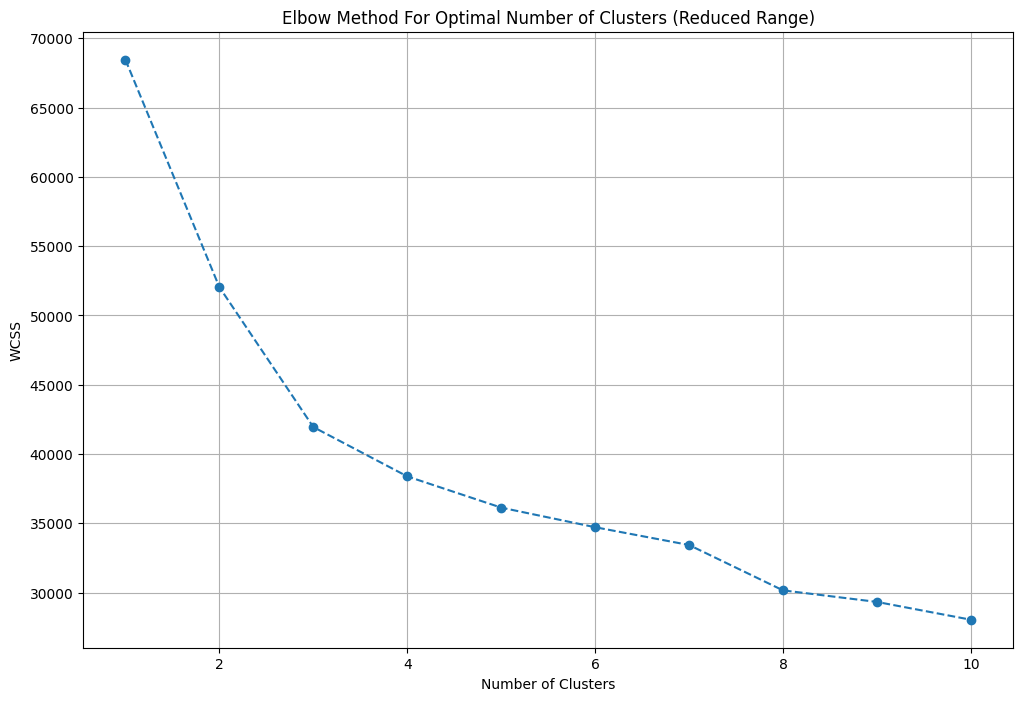

In [48]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [49]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [50]:
df.shape

(3803, 43)

In [51]:
df = df.iloc[:,:-18]  #removing the extra added 18 furnishing cols

In [52]:
df.shape

(3803, 25)

In [53]:
df['furnishing_type'] = cluster_assignments

In [54]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
2586,"['4 Wardrobe', '5 Fan', '4 Geyser', '2 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
2682,"['1 Water Purifier', '10 Fan', '1 Fridge', '1 Exhaust Fan', '10 Geyser', '23 Light', '10 AC', '10 TV', '1 Modular Kitchen', '10 Curtains', '10 Wardrobe', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Sofa', 'No Stove', 'No Washing Machine']",2
1053,"['4 Fan', '5 Light', '4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
281,"['4 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '8 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
1116,NaN,0


# 5. features

In [56]:
df[['society','features']].sample(5)

,society,features
1804,adani m2k oyster grande,"['Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
653,pareena mi casa,"['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"
2583,dlf regal gardens,"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'Centrally Air Conditioned', 'Maintenance Staff', 'Separate entry for servant room', 'No open drainage around', 'Recently Renovated', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"
2660,bestech park view residency,"['Security / Fire Alarm', 'Lift(s)', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
773,adani brahma samsara vilasa,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking']"


In [58]:
df['features'].isnull().sum()

np.int64(639)

In [59]:
app_df = pd.read_csv('/content/appartments.csv')

In [60]:
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [62]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [63]:
temp_df = df[df['features'].isnull()]

In [64]:
temp_df.shape

(639, 26)

In [67]:
x = temp_df.merge(app_df, left_on='society', right_on='PropertyName', how='left' )['TopFacilities']

In [68]:
df.loc[temp_df.index, 'features'] = x.values

In [69]:
df['features'].isnull().sum()

np.int64(484)

In [70]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [71]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [72]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
1412,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
2420,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1572,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
3613,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
916,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0


In [73]:
features_binary_df.shape

(3803, 130)

In [74]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

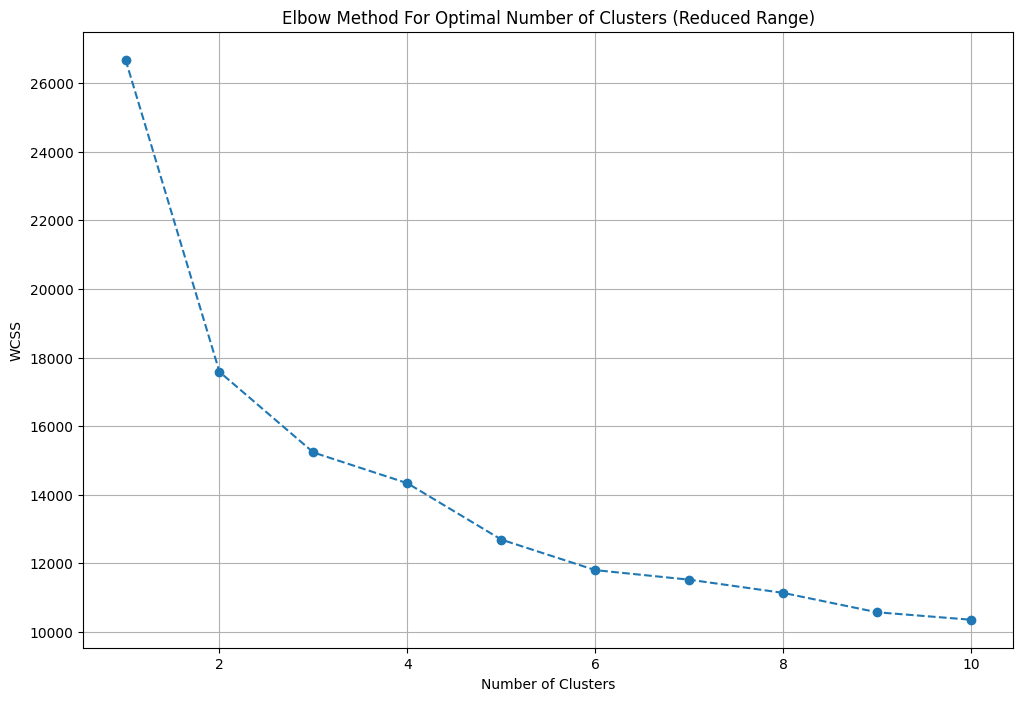

In [75]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Here in the above one, we got the info that it will be best fit if we take n_clusters for 2, but afterwards realized that it is just differentiating between, features given v/s where it is NaN.


## 2nd approach

In [76]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [77]:
df['luxury_score'] = luxury_score

In [78]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,indiabulls centrum park,sector 103,1.34,7882.0,1700.08,Super Built up area 1725(160.26 sq.m.)Carpet area: 1700 sq.ft. (157.94 sq.m.),3,3,3+,"pooja room,study room,servant room,store room",12.0,East,relatively new,"['Gurgaon Dreamz Mall', 'HUDA Market, Sector 14', 'Dwarka Expressway', 'Delhi Gurgaon Expressway', 'S N International School', 'The NorthCap University', 'Metro Hospital, Palam Vihar', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Emaar Business Park', 'Country Inn and Suites by Radisson', 'Sector 29 Gurgaon Pubs and Bars', 'HUDA Mini Golf Course', 'Infinitys Badminton Academy', 'F9 Go Karting Gurgaon']","['9 Fan', '9 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Lift(s)', 'Swimming Pool', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']",1725,NaN,1700.0,1,1,1,1,0,1,"[Lift(s), Swimming Pool, Park, Shopping Centre, Fitness Centre / GYM, Club house / Community Center, Rain Water Harvesting]",38
1,flat,mapsko royale ville,sector 82,1.15,6424.0,1790.16,Super Built up area 1790(166.3 sq.m.),3,4,2,"servant room,pooja room",15.0,North-East,relatively new,"['Sapphire 83 Mall', 'Golf Course Ext Rd', ""St. Xavier's High School"", 'DPG Institute of Technology', 'Miracles Apollo Cradle', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park', 'Vishalgarh Farms', 'F9 Go Karting Gurgaon']","['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '3 Geyser', '11 Light', '1 Chimney', '1 Modular Kitchen', '1 Curtains', 'No AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",1790,NaN,NaN,0,1,0,1,0,1,"[Security / Fire Alarm, Power Back-up, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), Water Storage, Separate entry for servant room, No open drainage around, Bank Attached Property, Visitor Parking, Swimming Pool, Park, Security Personnel, Internet/wi-fi connectivity, Low Density Society, Shopping Centre, Fitness Centre / GYM, Waste Disposal, Rain Water Harvesting, Club house / Community Center, Water softening plant]",104
2,flat,ss the leaf,sector 85,2.15,10924.0,1968.14,Super Built up area 2812(261.24 sq.m.)Carpet area: 1968 sq.ft. (182.83 sq.m.),4,5,3+,servant room,6.0,South,relatively new,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Central Peripheral Road', 'NH 08', 'Pataudi Road', 'Delhi Public School Sector 84', 'DPG Institute of Technology', 'Genesis Hospital Sector 84', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'SkyJumper Trampoline Park', 'Nakhrola Stadium Sector 81A']","['20 Light', '6 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', '

In [79]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'], inplace = True)

In [80]:
df.shape

(3803, 23)

In [82]:
df.to_csv('gurgaon_properties_cleaned_v2.csv', index=False)

In [81]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3386,flat,experion the heartsong,sector 108,0.93,6079.0,1529.86,Super Built up area 1283(119.19 sq.m.),2,3,3,10.0,East,relatively new,1283,NaN,NaN,0,0,0,0,0,0,81
3767,flat,bptp mansions park prime,sector 66,3.00,10853.0,2764.21,Super Built up area 2764(256.78 sq.m.)Built Up area: 2700 sq.ft. (250.84 sq.m.)Carpet area: 2500 sq.ft. (232.26 sq.m.),4,4,3,3.0,North,relatively new,2764,2700.0,2500.0,1,1,0,1,1,1,174
1420,flat,tarc maceo,sector 91,0.96,5413.0,1773.51,Super Built up area 1404(130.44 sq.m.),2,2,3+,8.0,East,moderately old,1404,NaN,NaN,0,0,0,0,0,0,85
2480,flat,ambience creacions,sector 22,1.75,12700.0,1377.95,Super Built up area 1380(128.21 sq.m.),2,2,2,11.0,NaN,Under Construction,1380,NaN,NaN,0,0,0,0,0,0,57
1796,house,independent,jacobpura,6.00,315789.0,190.00,Plot area 190(17.65 sq.m.)Carpet area: 1600 sq.ft. (148.64 sq.m.),9,6,2,2.0,North-East,Old Property,NaN,NaN,1600.0,0,0,0,0,0,0,0
